In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2255,9537-VHDTA,Female,0,No,Yes,1,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,51.20,51.2,No
4747,8884-FEEWR,Male,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),20.60,754,No
6485,5921-NGYRH,Male,0,Yes,No,64,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,73.55,4764,No
2190,5003-XZWWO,Male,0,Yes,No,71,Yes,Yes,DSL,No,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.20,5956.85,No
199,3645-DEYGF,Male,0,No,Yes,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.75,20.75,No
5303,9839-ETQOE,Male,0,No,Yes,43,No,No phone service,DSL,Yes,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,40.45,1912.85,No
2877,0310-MVLET,Female,0,Yes,Yes,61,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.15,6010.05,Yes
5640,5393-RXQSZ,Male,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,No,Electronic check,79.60,79.6,Yes
814,4785-NKHCX,Male,1,No,No,5,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.05,94.15,No
6271,6726-WEXXK,Male,1,Yes,No,27,Yes,Yes,Fiber optic,Yes,...,Yes,No,No,No,One year,Yes,Electronic check,85.90,2220.1,No


In [5]:
print(df.describe(include='all'))

        customerID gender  SeniorCitizen Partner Dependents       tenure  \
count         7043   7043    7043.000000    7043       7043  7043.000000   
unique        7043      2            NaN       2          2          NaN   
top     3186-AJIEK   Male            NaN      No         No          NaN   
freq             1   3555            NaN    3641       4933          NaN   
mean           NaN    NaN       0.162147     NaN        NaN    32.371149   
std            NaN    NaN       0.368612     NaN        NaN    24.559481   
min            NaN    NaN       0.000000     NaN        NaN     0.000000   
25%            NaN    NaN       0.000000     NaN        NaN     9.000000   
50%            NaN    NaN       0.000000     NaN        NaN    29.000000   
75%            NaN    NaN       0.000000     NaN        NaN    55.000000   
max            NaN    NaN       1.000000     NaN        NaN    72.000000   

       PhoneService MultipleLines InternetService OnlineSecurity  ...  \
count         

In [6]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [8]:
df.drop(columns=['customerID'],inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df['TotalCharges'].describe()

count     7043
unique    6531
top       20.2
freq        11
Name: TotalCharges, dtype: object

In [10]:
df['TotalCharges'].value_counts()

TotalCharges
20.2      11
          11
19.75      9
19.65      8
19.9       8
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
108.15     1
Name: count, Length: 6531, dtype: int64

In [11]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [12]:
df.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

<Axes: xlabel='TotalCharges', ylabel='Count'>

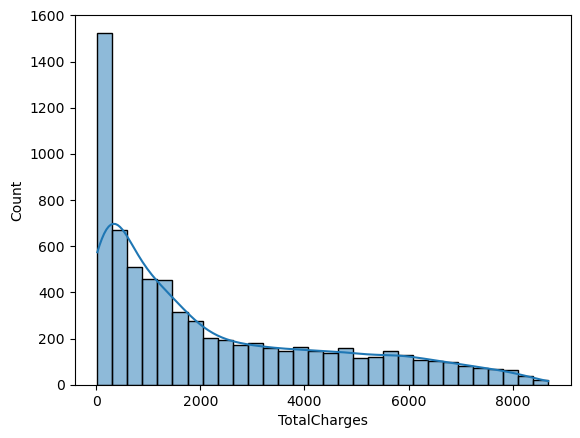

In [13]:
sns.histplot(data = df,x = 'TotalCharges',bins = 30,kde = 1)

In [14]:
df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)

In [15]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

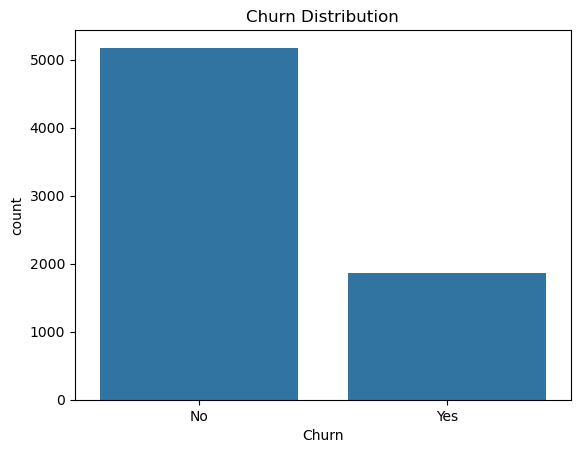

In [16]:
sns.countplot(data = df, x = 'Churn')
plt.title('Churn Distribution')
plt.show()

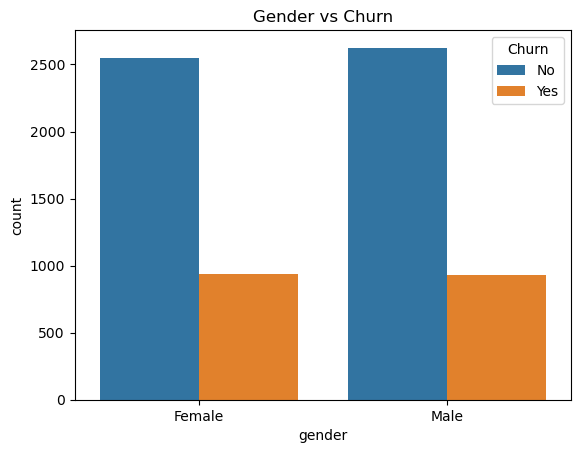

In [17]:
sns.countplot(data=df, x="gender", hue="Churn")
plt.title("Gender vs Churn")
plt.show()

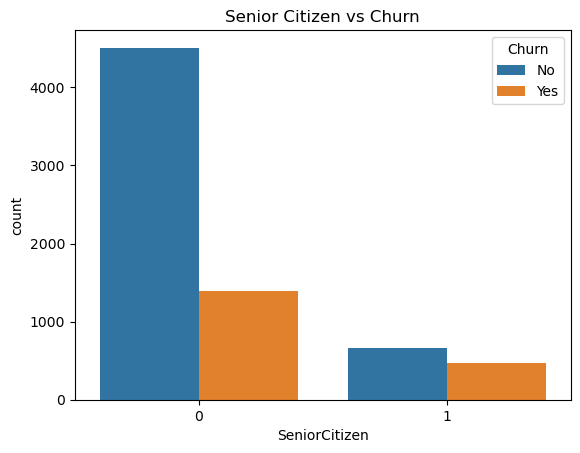

In [18]:
sns.countplot(data=df,x="SeniorCitizen",hue="Churn")
plt.title("Senior Citizen vs Churn")
plt.show()

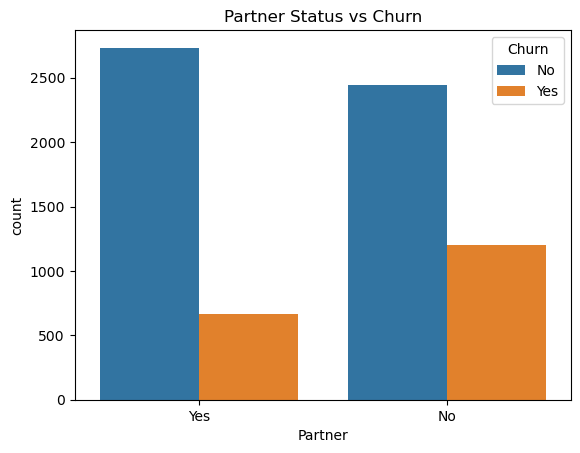

In [19]:
sns.countplot(data=df, x="Partner", hue="Churn")
plt.title("Partner Status vs Churn")
plt.show()

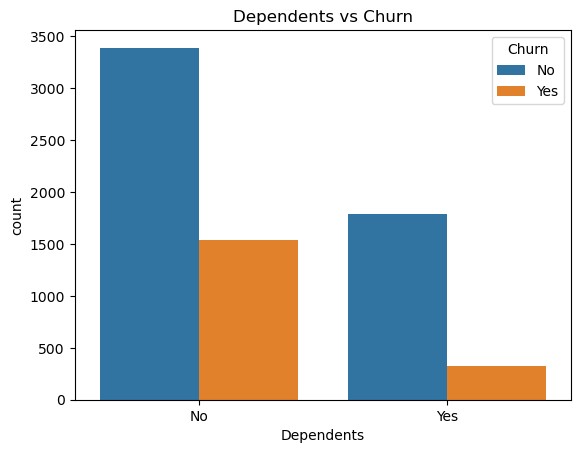

In [20]:
sns.countplot(data=df, x="Dependents", hue="Churn")
plt.title("Dependents vs Churn")
plt.show()

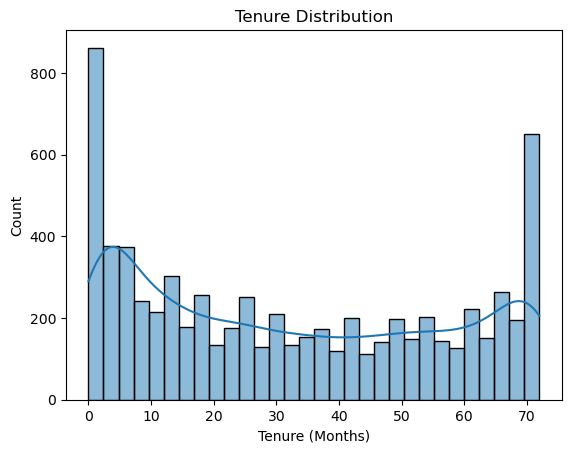

In [21]:
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.show()

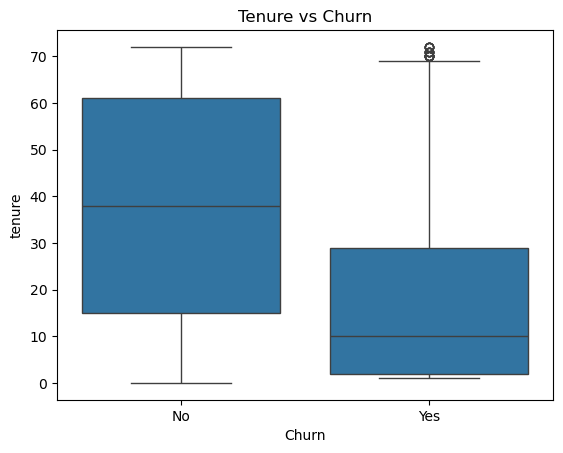

In [22]:
sns.boxplot(data=df,x="Churn",y="tenure")
plt.title("Tenure vs Churn")
plt.show()

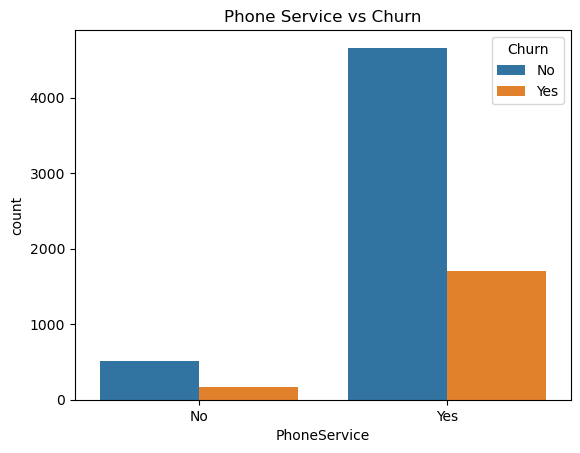

In [23]:
sns.countplot(data=df,x="PhoneService",hue="Churn")
plt.title("Phone Service vs Churn")
plt.show()

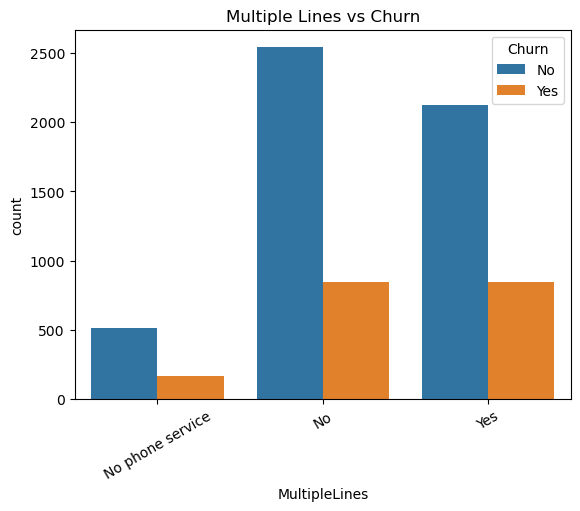

In [24]:
sns.countplot(data=df,x="MultipleLines",hue="Churn")
plt.xticks(rotation=30)
plt.title("Multiple Lines vs Churn")
plt.show()

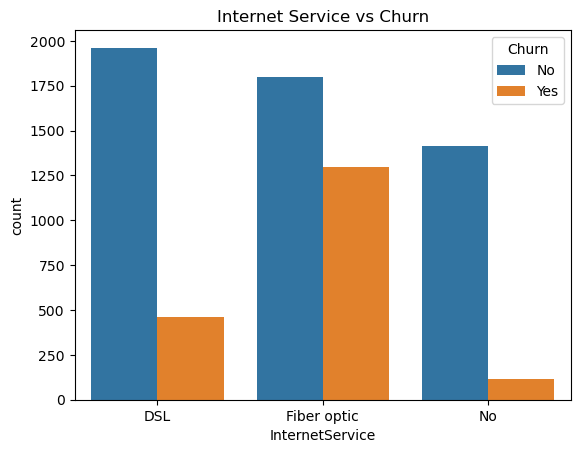

In [25]:
sns.countplot(data=df,x="InternetService",hue="Churn")
plt.title("Internet Service vs Churn")
plt.show()

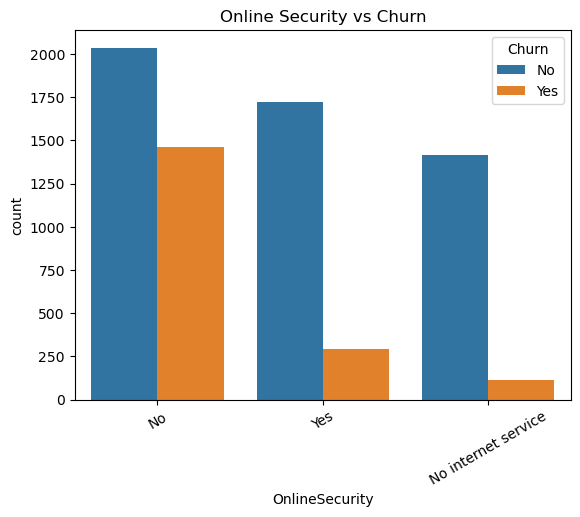

In [26]:
sns.countplot(data=df,x="OnlineSecurity",hue="Churn")
plt.xticks(rotation=30)
plt.title("Online Security vs Churn")
plt.show()

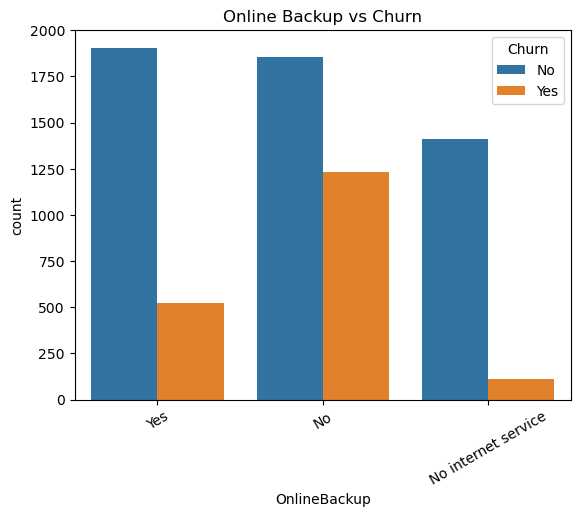

In [27]:
sns.countplot(data=df,x="OnlineBackup",hue="Churn")
plt.xticks(rotation=30)
plt.title("Online Backup vs Churn")
plt.show()

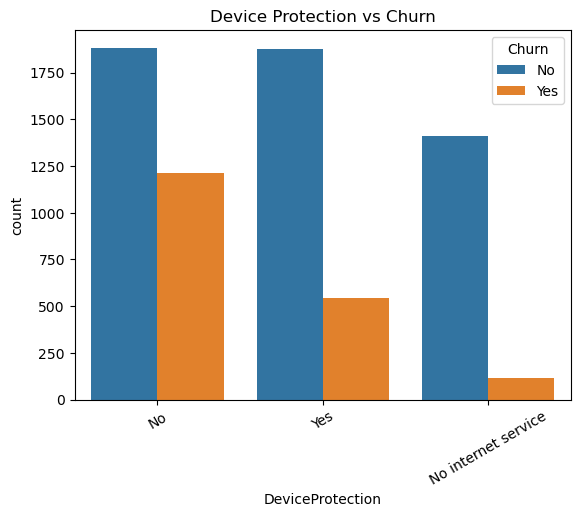

In [28]:
sns.countplot(data=df,x="DeviceProtection",hue="Churn")
plt.xticks(rotation=30)
plt.title("Device Protection vs Churn")
plt.show()

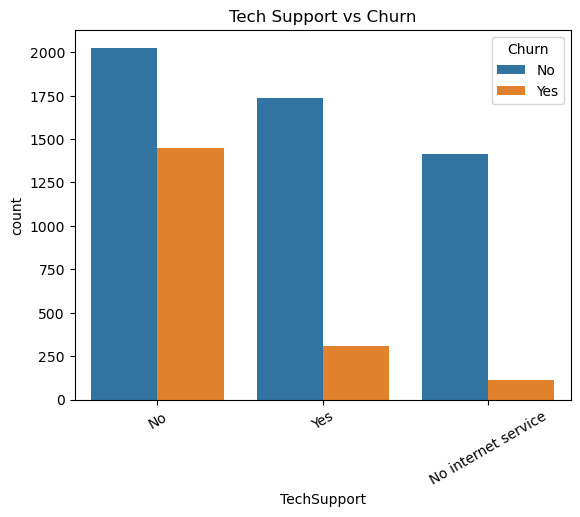

In [29]:
sns.countplot(data=df,x="TechSupport",hue="Churn")
plt.xticks(rotation=30)
plt.title("Tech Support vs Churn")
plt.show()

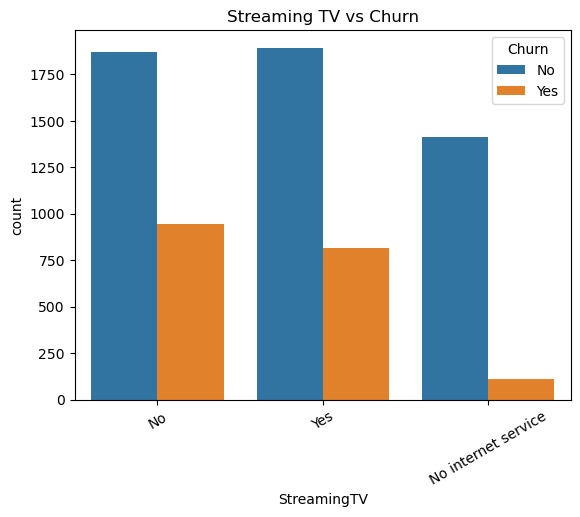

In [30]:
sns.countplot(data=df,x="StreamingTV",hue="Churn")
plt.xticks(rotation=30)
plt.title("Streaming TV vs Churn")
plt.show()

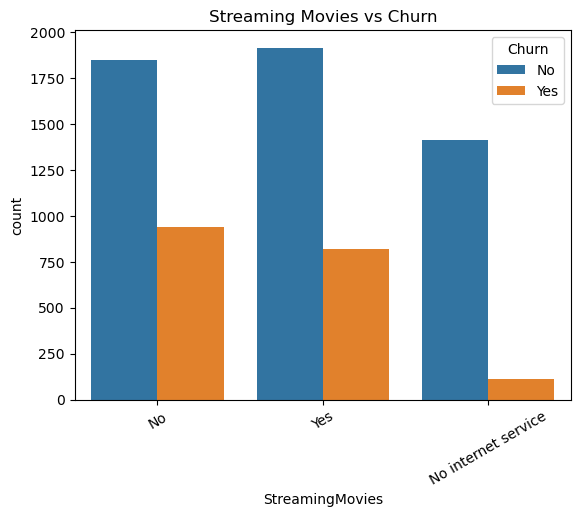

In [31]:
sns.countplot(data=df,x="StreamingMovies",hue="Churn")
plt.xticks(rotation=30)
plt.title("Streaming Movies vs Churn")
plt.show()

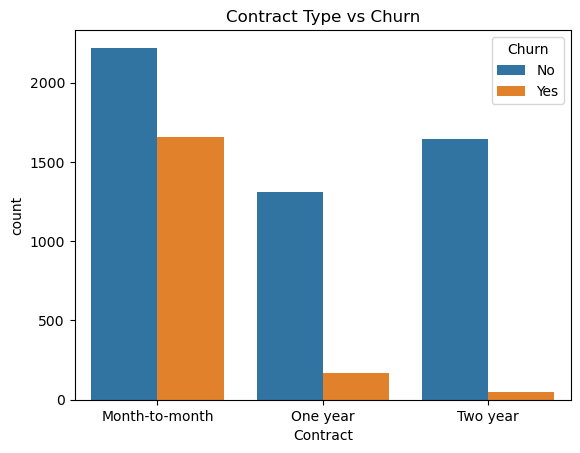

In [32]:
sns.countplot(data=df,x="Contract",hue="Churn")
plt.title("Contract Type vs Churn")
plt.show()

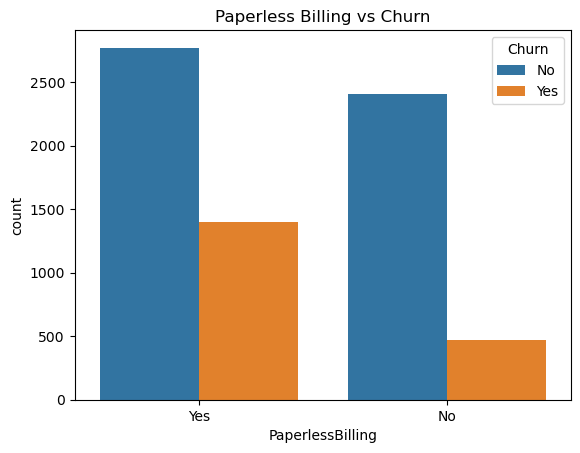

In [33]:
sns.countplot(data=df,x="PaperlessBilling",hue="Churn")
plt.title("Paperless Billing vs Churn")
plt.show()

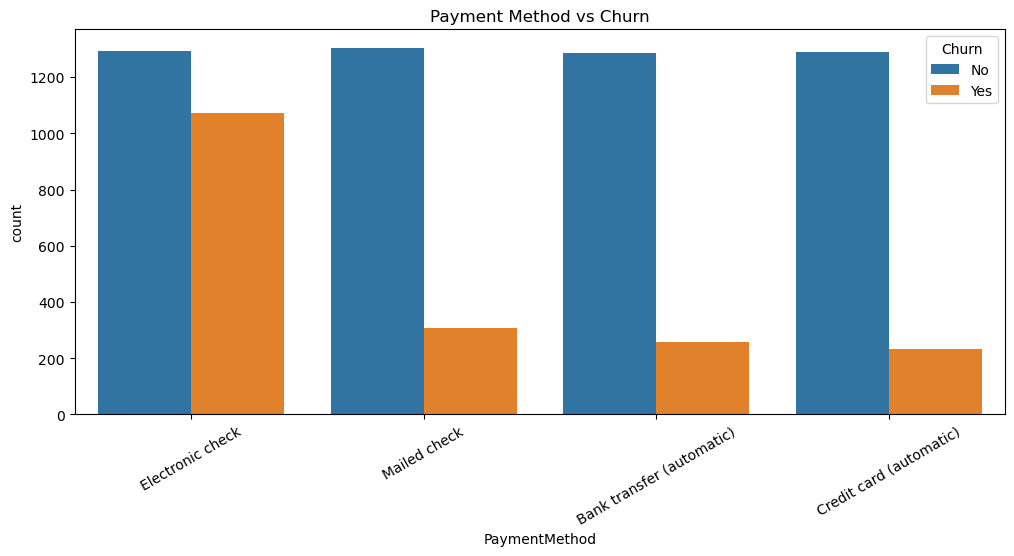

In [34]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df,x="PaymentMethod",hue="Churn")
plt.xticks(rotation=30)
plt.title("Payment Method vs Churn")
plt.show()

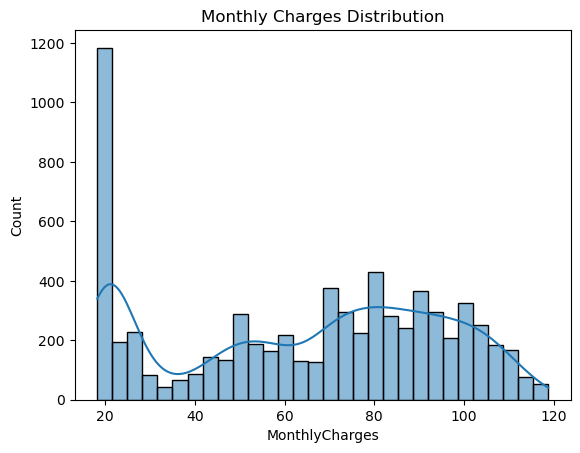

In [35]:
sns.histplot(df["MonthlyCharges"],bins=30,kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

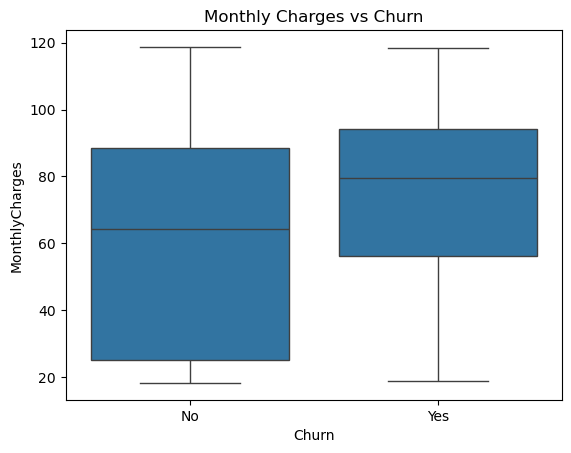

In [36]:
sns.boxplot(data=df,x="Churn",y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

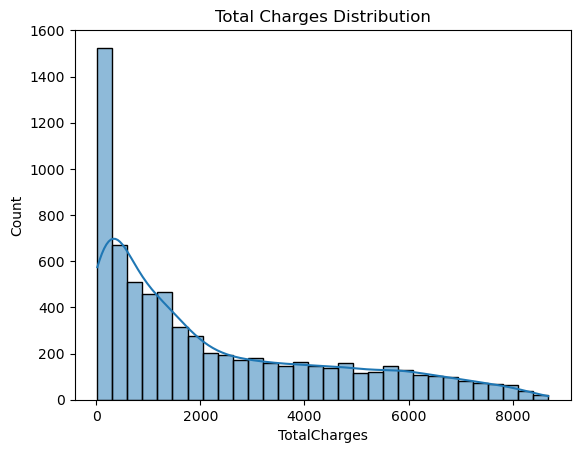

In [37]:
sns.histplot(df["TotalCharges"],bins=30,kde=True)
plt.title("Total Charges Distribution")
plt.show()

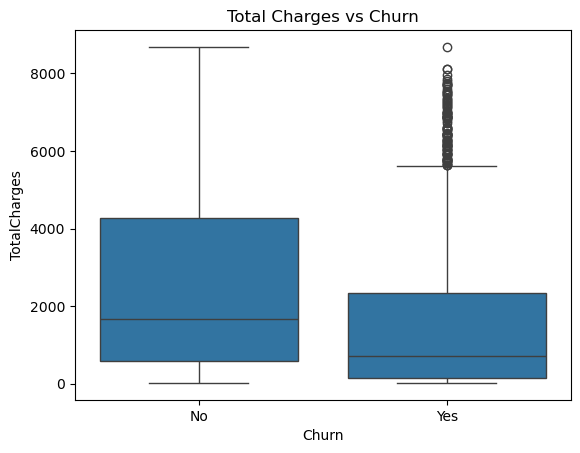

In [38]:
sns.boxplot(data=df,x="Churn",y="TotalCharges")
plt.title("Total Charges vs Churn")
plt.show()

In [39]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include="object").columns

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
Categorical: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


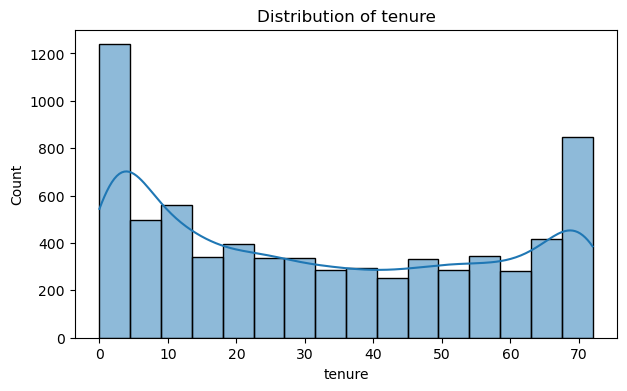

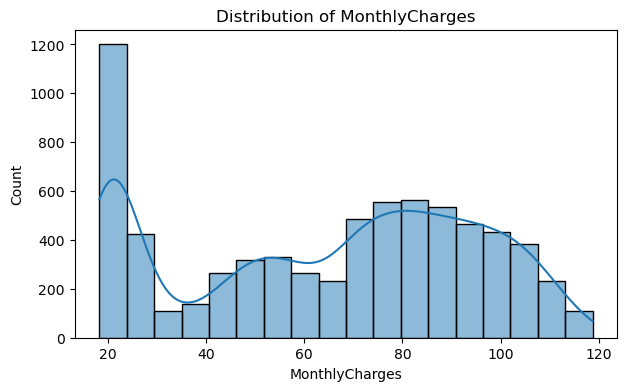

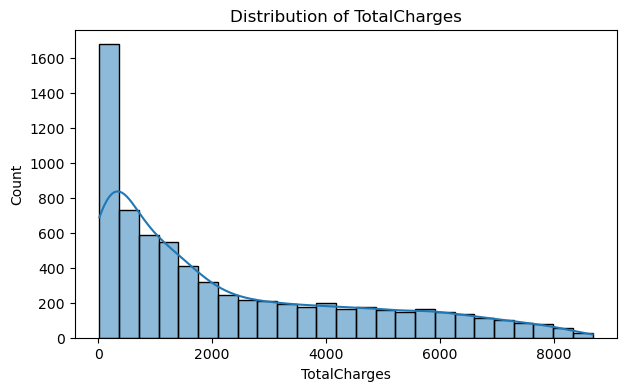

In [40]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

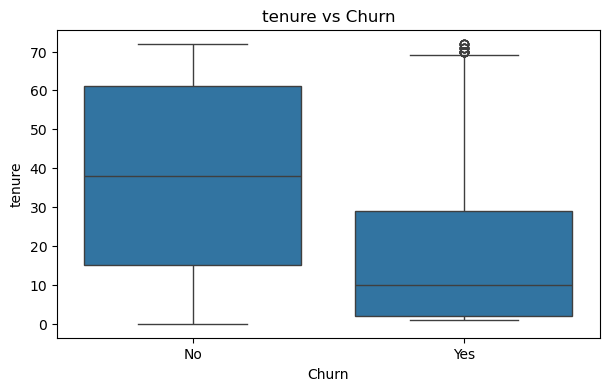

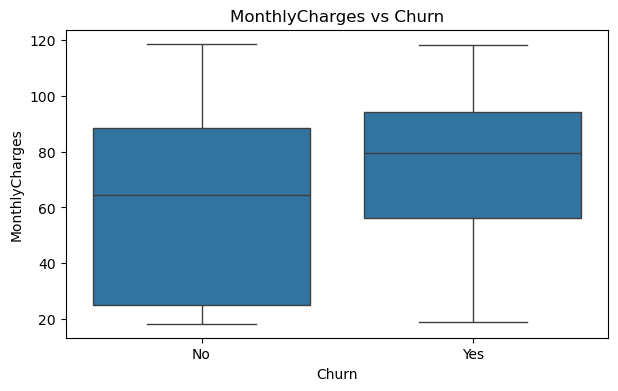

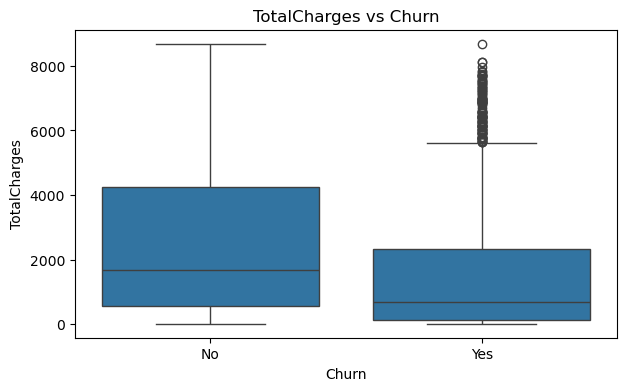

In [41]:
for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} vs Churn")
    plt.show()

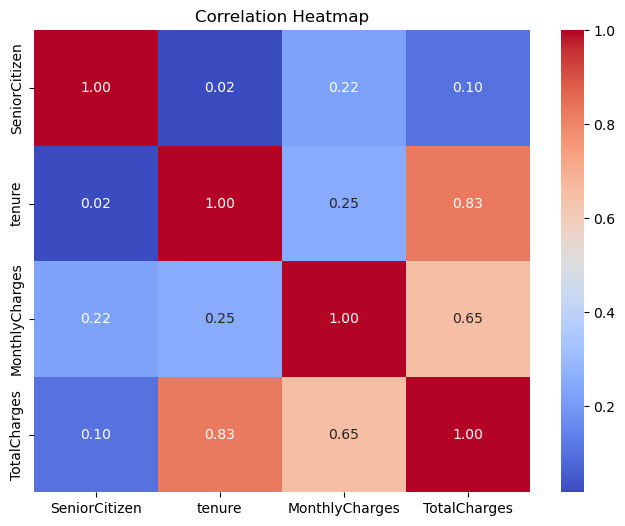

In [42]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

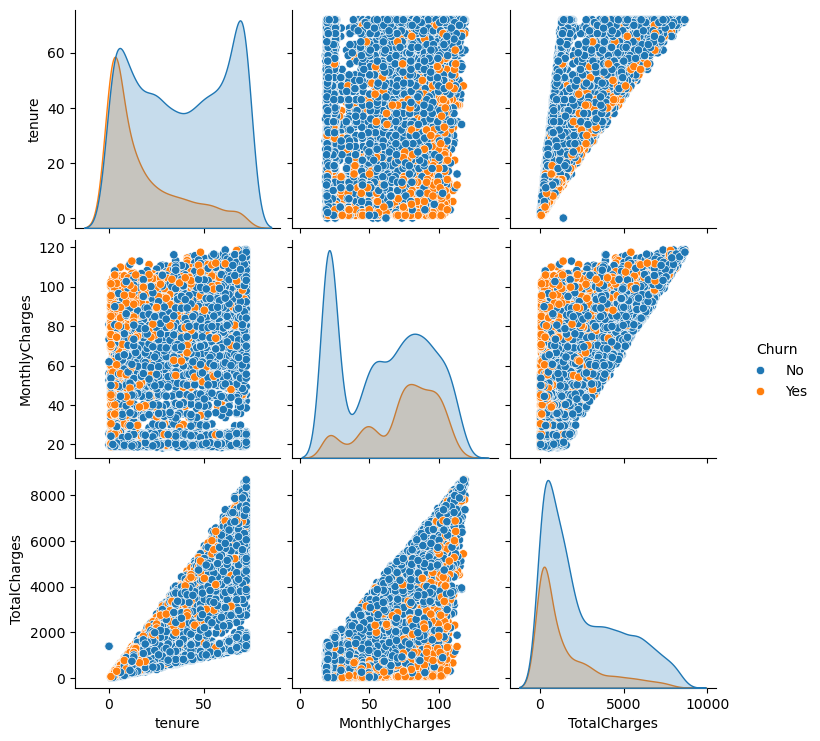

In [43]:
sns.pairplot(
    df[
        ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
    ],
    hue="Churn"
)

plt.show()